# K-Nearest Neighbors (KNN): A Complete Machine Learning Lesson

This notebook is a **full, self-contained study guide for K-Nearest Neighbors (KNN)**.

The goal is not only to use `scikit-learn`, but to understand the algorithm from first principles:

1. Machine learning intuition behind KNN
2. Geometric interpretation
3. Distance mathematics
4. Euclidean, Manhattan, and Minkowski distance
5. Why feature scaling matters
6. KNN Classification
7. Majority voting
8. Distance-weighted KNN
9. KNN Regression
10. Choosing `K`
11. Bias, variance, overfitting, and underfitting
12. Decision boundaries
13. `mglearn` visualizations
14. A KNN implementation from scratch
15. Scikit-learn implementation
16. Cross-validation
17. Hyperparameter tuning with `GridSearchCV`
18. Pipelines and leakage prevention
19. Classification metrics
20. Confusion matrix and probability estimates
21. Curse of dimensionality
22. Strengths, weaknesses, and common mistakes
23. A practical end-to-end workflow

The teaching structure is:

**Intuition → Mathematics → From Scratch → Scikit-learn → Visualization → Evaluation → Failure Cases → Practical Workflow**

## Learning Objectives

After completing this notebook, you should be able to:

- Explain why KNN is called an **instance-based** and **lazy** learning algorithm.
- Derive and calculate the main distance functions used by KNN.
- Explain exactly what `K` means.
- Distinguish classification from regression in KNN.
- Explain why scaling is usually essential for KNN.
- Describe the relationship between `K`, bias, variance, overfitting, and underfitting.
- Implement a simple KNN classifier **without scikit-learn**.
- Build a robust KNN model with `Pipeline`.
- Choose hyperparameters with cross-validation.
- Interpret KNN decision boundaries.
- Understand why high-dimensional biological data can be difficult for distance-based methods.

## 1. Imports and Notebook Setup

The code below imports the main packages used throughout the lesson.

`mglearn` is intentionally included because it is useful for teaching machine-learning concepts visually.

### If `mglearn` is not installed

Run the optional installation cell below in your own environment:

```python
%pip install mglearn
```

Then restart the kernel if your environment asks you to.

In [1]:
# Optional: install mglearn if it is not already installed.
# Run this cell only when mglearn is missing from your environment.
# %pip install mglearn

# Import NumPy for numerical arrays and mathematical operations.
import numpy as np

# Import pandas for table-like data manipulation.
import pandas as pd

# Import Matplotlib for general-purpose plotting.
import matplotlib.pyplot as plt

# Import Seaborn for statistical visualization and cleaner plots.
import seaborn as sns

# Import mglearn for educational machine-learning visualizations.
# This package is especially useful for decision-boundary demonstrations.
try:
    import mglearn
except ImportError as error:
    raise ImportError(
        "mglearn is not installed. Run `%pip install mglearn` "
        "in a notebook cell, restart the kernel, and run the notebook again."
    ) from error

# Import train_test_split for separating data into training and test subsets.
from sklearn.model_selection import train_test_split

# Import cross-validation utilities for model selection.
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold

# Import GridSearchCV for systematic hyperparameter tuning.
from sklearn.model_selection import GridSearchCV

# Import StandardScaler for feature standardization.
from sklearn.preprocessing import StandardScaler

# Import Pipeline so preprocessing and the model stay together.
from sklearn.pipeline import Pipeline

# Import synthetic-data generators for controlled experiments.
from sklearn.datasets import make_classification
from sklearn.datasets import make_moons
from sklearn.datasets import make_regression

# Import the KNN classifier and regressor.
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import NearestNeighbors

# Import evaluation metrics for classification.
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

# Make printed NumPy arrays easier to read.
np.set_printoptions(precision=3, suppress=True)

# Set a readable Seaborn theme for the notebook figures.
sns.set_theme(style="whitegrid", context="notebook")

# Print the main library versions used by the notebook.
import sklearn

print("NumPy version:", np.__version__)
print("pandas version:", pd.__version__)
print("scikit-learn version:", sklearn.__version__)
print("mglearn imported successfully.")

NumPy version: 2.4.6
pandas version: 3.0.3
scikit-learn version: 1.9.0
mglearn imported successfully.


## 2. What Is KNN?

**K-Nearest Neighbors (KNN)** is a supervised learning algorithm that can be used for both:

- **Classification**
- **Regression**

The central idea is:

> A new observation is predicted using the observations that are closest to it in feature space.

Unlike models such as linear regression, KNN does not learn a small set of global coefficients such as:

$$
y = \beta_0 + \beta_1x_1 + \beta_2x_2
$$

Instead, KNN keeps the training examples and performs most of its work when a new observation must be predicted.

That is why KNN is often described as:

- **Instance-based learning**
- **Lazy learning**

### Important distinction

KNN does not mean:

> "Find examples that look similar according to human intuition."

It means:

> "Define a mathematical distance, compute that distance in feature space, and use the closest observations."

## 3. A Simple Geometric Example

Suppose we have two classes of observations:

- Class 0
- Class 1

Every observation has two numerical features.

For a new point $x_{\text{new}}$, KNN:

1. Computes its distance to every training point.
2. Sorts the distances.
3. Selects the closest $K$ observations.
4. Uses those neighbors to make the prediction.

For classification, the usual rule is **majority voting**.

For regression, the usual rule is an **average**.

This means that KNN is fundamentally a **neighborhood-based** method.

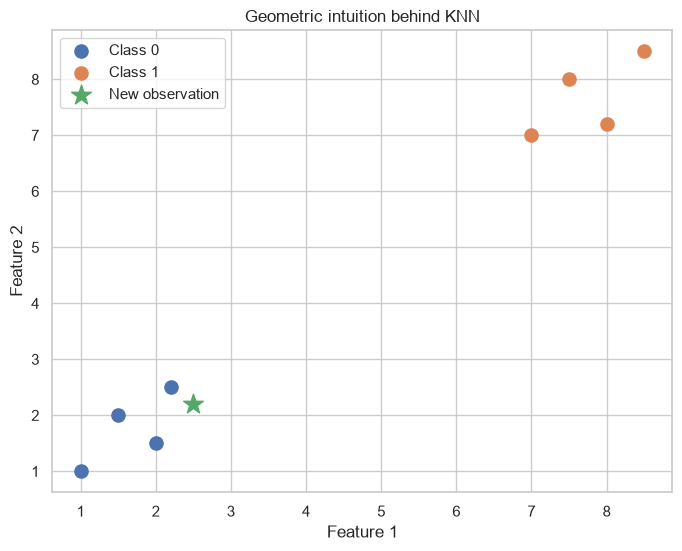

In [2]:
# Create a small two-dimensional example for visualization.
# The first column represents feature X1.
# The second column represents feature X2.
X_demo = np.array([
    [1.0, 1.0],
    [1.5, 2.0],
    [2.0, 1.5],
    [2.2, 2.5],
    [7.0, 7.0],
    [7.5, 8.0],
    [8.0, 7.2],
    [8.5, 8.5]
])

# Define the class label for each observation.
y_demo = np.array([
    0, 0, 0, 0,
    1, 1, 1, 1
])

# Define one new observation whose class we want to predict.
x_new_demo = np.array([2.5, 2.2])

# Create the figure.
plt.figure(figsize=(8, 6))

# Plot class 0 observations.
plt.scatter(
    X_demo[y_demo == 0, 0],
    X_demo[y_demo == 0, 1],
    label="Class 0",
    s=90
)

# Plot class 1 observations.
plt.scatter(
    X_demo[y_demo == 1, 0],
    X_demo[y_demo == 1, 1],
    label="Class 1",
    s=90
)

# Plot the new observation with a star marker.
plt.scatter(
    x_new_demo[0],
    x_new_demo[1],
    marker="*",
    s=220,
    label="New observation"
)

# Label the horizontal axis.
plt.xlabel("Feature 1")

# Label the vertical axis.
plt.ylabel("Feature 2")

# Add a descriptive title.
plt.title("Geometric intuition behind KNN")

# Display the legend.
plt.legend()

# Display the plot.
plt.show()

# 4. The Mathematics of KNN

The mathematics of KNN is less about estimating model parameters and more about defining **similarity through distance**.

Let a training observation be:

$$
X_i = (x_{i1}, x_{i2}, \ldots, x_{id})
$$

and let a new observation be:

$$
X_{\text{new}} = (x_1, x_2, \ldots, x_d)
$$

KNN needs a distance function:

$$
d(X_{\text{new}}, X_i)
$$

The distance is then calculated for every training sample.

The neighbors are the $K$ samples with the smallest distances.

## 4.1 Euclidean Distance

For two points in two dimensions,

$$
A=(x_1,x_2)
$$

and

$$
B=(y_1,y_2)
$$

the Euclidean distance is:

$$
d(A,B)
=
\sqrt{(x_1-y_1)^2+(x_2-y_2)^2}
$$

This is the familiar straight-line distance from geometry.

### Example

Let:

$$
A=(2,3)
$$

and:

$$
B=(5,7)
$$

Then:

$$
d(A,B)
=
\sqrt{(2-5)^2+(3-7)^2}
$$

$$
=
\sqrt{(-3)^2+(-4)^2}
$$

$$
=
\sqrt{9+16}
=
\sqrt{25}
=
5
$$

In [3]:
# Define the first point.
A = np.array([2.0, 3.0])

# Define the second point.
B = np.array([5.0, 7.0])

# Calculate the difference between corresponding coordinates.
difference = A - B

# Square each coordinate difference.
squared_difference = difference ** 2

# Add the squared differences.
sum_squared_difference = np.sum(squared_difference)

# Take the square root to obtain Euclidean distance.
euclidean_distance = np.sqrt(sum_squared_difference)

# Print every intermediate result so the calculation is transparent.
print("A:", A)
print("B:", B)
print("Difference:", difference)
print("Squared difference:", squared_difference)
print("Sum of squared differences:", sum_squared_difference)
print("Euclidean distance:", euclidean_distance)

A: [2. 3.]
B: [5. 7.]
Difference: [-3. -4.]
Squared difference: [ 9. 16.]
Sum of squared differences: 25.0
Euclidean distance: 5.0


## 4.2 Euclidean Distance in $d$ Dimensions

For $d$ features:

$$
d(X,Y)
=
\sqrt{
\sum_{j=1}^{d}(X_j-Y_j)^2
}
$$

For example, if a patient is represented by:

$$
X=(Age, TumorSize, KPS)
$$

then all three dimensions contribute to the distance.

This is exactly why feature scale and feature selection matter so much in KNN.

## 4.3 Manhattan Distance

Manhattan distance is:

$$
d(X,Y)
=
\sum_{j=1}^{d}|X_j-Y_j|
$$

For two dimensions:

$$
d(A,B)
=
|x_1-y_1|+|x_2-y_2|
$$

It is often described as a "city-block" distance because movement happens along coordinate axes.

In [4]:
# Define two points for the distance comparison.
A = np.array([2.0, 3.0])
B = np.array([5.0, 7.0])

# Calculate Euclidean distance.
euclidean = np.sqrt(np.sum((A - B) ** 2))

# Calculate Manhattan distance.
manhattan = np.sum(np.abs(A - B))

# Print both values for comparison.
print("Euclidean distance:", euclidean)
print("Manhattan distance:", manhattan)

Euclidean distance: 5.0
Manhattan distance: 7.0


## 4.4 Minkowski Distance

Minkowski distance generalizes several common distance functions:

$$
d(X,Y)
=
\left(
\sum_{j=1}^{d}|X_j-Y_j|^p
\right)^{1/p}
$$

Special cases:

- $p=1$ → Manhattan distance
- $p=2$ → Euclidean distance

In scikit-learn:

```python
metric="minkowski"
```

and:

```python
p=1
```

corresponds to Manhattan distance, while:

```python
p=2
```

corresponds to Euclidean distance.

In [5]:
# Store two points as NumPy arrays.
A = np.array([2.0, 3.0])
B = np.array([5.0, 7.0])

# Define p = 1 for Manhattan distance.
p1 = 1

# Compute the Minkowski distance with p = 1.
minkowski_p1 = np.sum(np.abs(A - B) ** p1) ** (1 / p1)

# Define p = 2 for Euclidean distance.
p2 = 2

# Compute the Minkowski distance with p = 2.
minkowski_p2 = np.sum(np.abs(A - B) ** p2) ** (1 / p2)

# Display the two special cases.
print("Minkowski with p=1:", minkowski_p1)
print("Minkowski with p=2:", minkowski_p2)

Minkowski with p=1: 7.0
Minkowski with p=2: 5.0


# 5. How KNN Finds the Neighbors

Suppose a new sample is:

$$
X_{\text{new}}=(3,2)
$$

and the training samples are:

| Sample | $x_1$ | $x_2$ | Class |
|---|---:|---:|---:|
| A | 1 | 1 | 0 |
| B | 2 | 2 | 0 |
| C | 2 | 3 | 0 |
| D | 8 | 8 | 1 |
| E | 9 | 9 | 1 |

For every training observation we calculate:

$$
d(X_{\text{new}}, X_i)
$$

Then we sort these values.

The smallest distances define the nearest neighbors.

This is the core algorithm.

In [6]:
# Create a simple training dataset.
X_small = np.array([
    [1.0, 1.0],
    [2.0, 2.0],
    [2.0, 3.0],
    [8.0, 8.0],
    [9.0, 9.0]
])

# Store the class labels for the training observations.
y_small = np.array([0, 0, 0, 1, 1])

# Define the new observation.
x_new = np.array([3.0, 2.0])

# Create an empty list that will store distances.
distance_table = []

# Loop over every training observation.
for i, x_train in enumerate(X_small):

    # Calculate Euclidean distance from the new observation.
    distance = np.sqrt(np.sum((x_train - x_new) ** 2))

    # Store the index, distance, and class together.
    distance_table.append((i, distance, y_small[i]))

# Sort the list by distance.
distance_table.sort(key=lambda row: row[1])

# Print the sorted neighbors.
print("Index | Distance | Class")
print("-" * 24)

# Loop through the sorted distance information.
for index, distance, label in distance_table:

    # Print each row in a readable format.
    print(f"{index:5d} | {distance:8.3f} | {label}")

Index | Distance | Class
------------------------
    1 |    1.000 | 0
    2 |    1.414 | 0
    0 |    2.236 | 0
    3 |    7.810 | 1
    4 |    9.220 | 1


# 6. KNN Classification

For classification, the prediction is commonly based on majority voting.

Let:

$$
N_k(x)
$$

denote the set of the $K$ nearest neighbors of observation $x$.

Then the predicted class can be written conceptually as:

$$
\hat y
=
\arg\max_c
\sum_{i \in N_k(x)}
\mathbf{1}(y_i=c)
$$

where:

$$
\mathbf{1}(y_i=c)
$$

is an indicator that equals 1 when the neighbor belongs to class $c$, and 0 otherwise.

In [7]:
# Create a simple classification dataset.
X_class = np.array([
    [1.0, 1.0],
    [1.5, 1.8],
    [2.0, 1.2],
    [2.2, 2.0],
    [7.0, 7.0],
    [7.5, 7.8],
    [8.0, 7.2],
    [8.5, 8.2]
])

# Create the class labels.
y_class = np.array([0, 0, 0, 0, 1, 1, 1, 1])

# Create a new observation near Class 0.
x_new = np.array([2.0, 2.1])

# Define K = 3.
k = 3

# Calculate all distances to the new observation.
distances = np.sqrt(np.sum((X_class - x_new) ** 2, axis=1))

# Sort the indices according to distance.
nearest_indices = np.argsort(distances)[:k]

# Extract the labels of the K nearest neighbors.
neighbor_labels = y_class[nearest_indices]

# Count how many times each class occurs.
classes, counts = np.unique(
    neighbor_labels,
    return_counts=True
)

# Select the class with the largest vote count.
prediction = classes[np.argmax(counts)]

# Display the result.
print("Nearest indices:", nearest_indices)
print("Neighbor labels:", neighbor_labels)
print("Vote counts:", dict(zip(classes, counts)))
print("Predicted class:", prediction)

Nearest indices: [3 1 2]
Neighbor labels: [0 0 0]
Vote counts: {np.int64(0): np.int64(3)}
Predicted class: 0


## 6.1 Why K=1 Can Overfit

When:

$$
K=1
$$

the model essentially asks:

> "What is the label of the single closest training observation?"

This makes the decision boundary very flexible.

A small noisy region around one training point can affect the prediction strongly.

That is why very small $K$ values often have:

- low bias
- high variance
- higher overfitting risk

## 6.2 Why Large K Can Underfit

When $K$ becomes very large, many distant points participate in the prediction.

The model becomes smoother and less sensitive to local structure.

This often means:

- higher bias
- lower variance
- higher underfitting risk

The correct $K$ is therefore data-dependent and should be selected using validation or cross-validation rather than by intuition alone.

# 7. Visualizing KNN with `mglearn`

`mglearn` was created as an educational helper library for machine-learning examples.

One particularly useful feature is its ability to visualize **2D decision boundaries**.

We will use a two-moons dataset because it creates a nonlinear classification problem that is easy to understand visually.

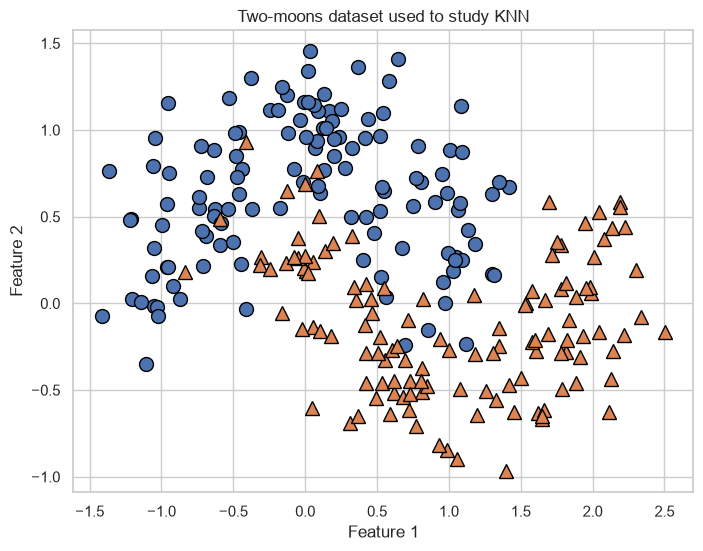

In [8]:
# Create a nonlinear two-class dataset with two interleaving half-moons.
X_moons, y_moons = make_moons(
    n_samples=250,
    noise=0.25,
    random_state=42
)

# Split the dataset into training and test sets.
X_moons_train, X_moons_test, y_moons_train, y_moons_test = train_test_split(
    X_moons,
    y_moons,
    test_size=0.25,
    random_state=42,
    stratify=y_moons
)

# Create a figure for the raw dataset.
plt.figure(figsize=(8, 6))

# Use mglearn to draw the two classes with different markers.
mglearn.discrete_scatter(
    X_moons[:, 0],
    X_moons[:, 1],
    y_moons
)

# Label the horizontal axis.
plt.xlabel("Feature 1")

# Label the vertical axis.
plt.ylabel("Feature 2")

# Add a title.
plt.title("Two-moons dataset used to study KNN")

# Display the plot.
plt.show()

## 7.1 Decision Boundary with K=1

For `K=1`, the decision boundary can become very irregular because each training point can dominate a local neighborhood.

This is a useful visual demonstration of high variance.

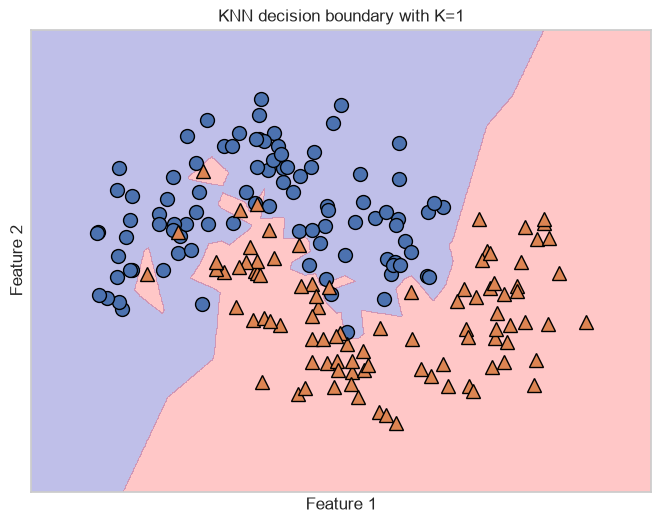

Training accuracy: 1.0
Test accuracy: 0.873015873015873


In [9]:
# Create a KNN classifier with one neighbor.
knn_k1 = KNeighborsClassifier(
    n_neighbors=1
)

# Fit the model on the training data.
knn_k1.fit(
    X_moons_train,
    y_moons_train
)

# Create a new figure.
plt.figure(figsize=(8, 6))

# Plot the decision boundary using mglearn.
mglearn.plots.plot_2d_separator(
    knn_k1,
    X_moons_train,
    fill=True,
    eps=0.5,
    alpha=0.25
)

# Overlay the training observations.
mglearn.discrete_scatter(
    X_moons_train[:, 0],
    X_moons_train[:, 1],
    y_moons_train
)

# Label the axes.
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Add the title.
plt.title("KNN decision boundary with K=1")

# Show the figure.
plt.show()

# Evaluate training accuracy.
print(
    "Training accuracy:",
    accuracy_score(
        y_moons_train,
        knn_k1.predict(X_moons_train)
    )
)

# Evaluate test accuracy.
print(
    "Test accuracy:",
    accuracy_score(
        y_moons_test,
        knn_k1.predict(X_moons_test)
    )
)

## 7.2 Decision Boundary with K=3

With a slightly larger neighborhood, the boundary becomes smoother.

This illustrates an important principle:

> Increasing $K$ reduces local sensitivity.

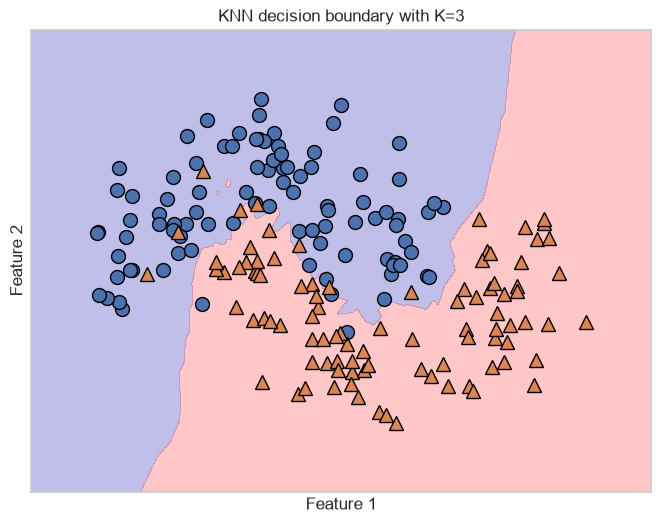

Training accuracy: 0.93048128342246
Test accuracy: 0.9206349206349206


In [10]:
# Create a KNN classifier with three neighbors.
knn_k3 = KNeighborsClassifier(
    n_neighbors=3
)

# Fit the model on the training data.
knn_k3.fit(
    X_moons_train,
    y_moons_train
)

# Create a new figure.
plt.figure(figsize=(8, 6))

# Plot the decision boundary with mglearn.
mglearn.plots.plot_2d_separator(
    knn_k3,
    X_moons_train,
    fill=True,
    eps=0.5,
    alpha=0.25
)

# Overlay the training observations.
mglearn.discrete_scatter(
    X_moons_train[:, 0],
    X_moons_train[:, 1],
    y_moons_train
)

# Label the axes.
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Add a title.
plt.title("KNN decision boundary with K=3")

# Display the plot.
plt.show()

# Print train and test accuracy.
print(
    "Training accuracy:",
    accuracy_score(
        y_moons_train,
        knn_k3.predict(X_moons_train)
    )
)

print(
    "Test accuracy:",
    accuracy_score(
        y_moons_test,
        knn_k3.predict(X_moons_test)
    )
)

## 7.3 Decision Boundary with K=15

A larger neighborhood should produce a smoother decision boundary.

The important lesson is not that K=15 is always better. The lesson is that **model complexity changes as K changes**.

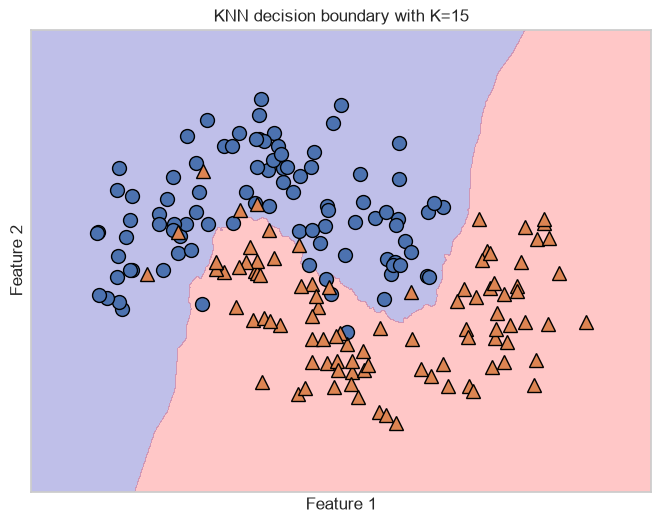

Training accuracy: 0.9411764705882353
Test accuracy: 0.9365079365079365


In [11]:
# Create a KNN classifier with fifteen neighbors.
knn_k15 = KNeighborsClassifier(
    n_neighbors=15
)

# Fit the model on the training data.
knn_k15.fit(
    X_moons_train,
    y_moons_train
)

# Create a new figure.
plt.figure(figsize=(8, 6))

# Plot the decision boundary with mglearn.
mglearn.plots.plot_2d_separator(
    knn_k15,
    X_moons_train,
    fill=True,
    eps=0.5,
    alpha=0.25
)

# Overlay the training observations.
mglearn.discrete_scatter(
    X_moons_train[:, 0],
    X_moons_train[:, 1],
    y_moons_train
)

# Label the axes.
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Add a title.
plt.title("KNN decision boundary with K=15")

# Show the plot.
plt.show()

# Print train and test accuracy.
print(
    "Training accuracy:",
    accuracy_score(
        y_moons_train,
        knn_k15.predict(X_moons_train)
    )
)

print(
    "Test accuracy:",
    accuracy_score(
        y_moons_test,
        knn_k15.predict(X_moons_test)
    )
)

# 8. Choosing K: Underfitting vs Overfitting

Instead of choosing $K$ arbitrarily, we can evaluate several values.

A useful experiment is to calculate:

- training accuracy
- validation accuracy

for many K values.

Typical behavior:

- very small K → training score can be extremely high, while validation performance may be lower
- moderate K → generalization may improve
- very large K → both training and validation performance can deteriorate because the model becomes too smooth

The exact curve depends on the dataset.

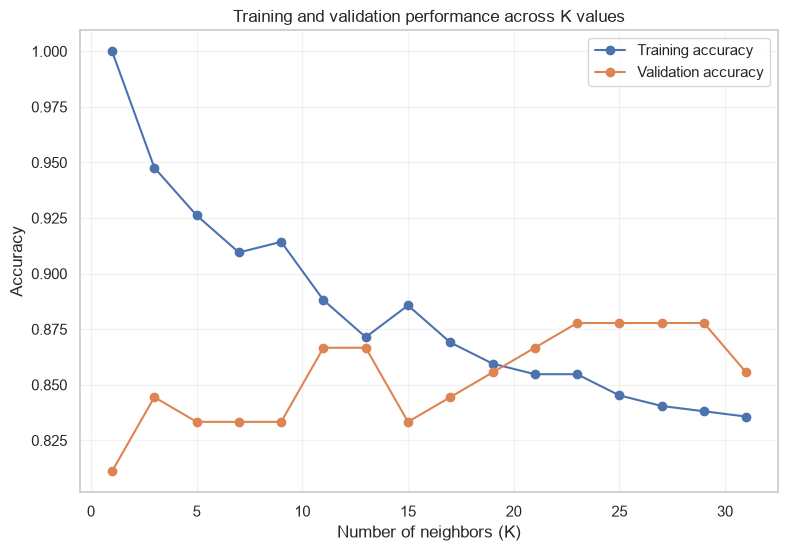

In [12]:
# Create a new synthetic binary classification dataset.
X_curve, y_curve = make_classification(
    n_samples=600,
    n_features=6,
    n_informative=4,
    n_redundant=0,
    class_sep=1.2,
    random_state=42
)

# Split the data into training and temporary sets.
X_curve_train, X_curve_temp, y_curve_train, y_curve_temp = train_test_split(
    X_curve,
    y_curve,
    test_size=0.30,
    random_state=42,
    stratify=y_curve
)

# Split the temporary data equally into validation and test sets.
X_curve_val, X_curve_test, y_curve_val, y_curve_test = train_test_split(
    X_curve_temp,
    y_curve_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_curve_temp
)

# Create a pipeline that standardizes features before KNN.
curve_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

# Create a range of odd K values to reduce binary-vote ties.
k_values = list(range(1, 32, 2))

# Create empty lists for storing the scores.
train_scores = []
validation_scores = []

# Evaluate each K value.
for k in k_values:

    # Update the number of neighbors inside the pipeline.
    curve_pipeline.set_params(knn__n_neighbors=k)

    # Fit the pipeline on training data only.
    curve_pipeline.fit(
        X_curve_train,
        y_curve_train
    )

    # Predict the training data.
    train_prediction = curve_pipeline.predict(
        X_curve_train
    )

    # Predict the validation data.
    validation_prediction = curve_pipeline.predict(
        X_curve_val
    )

    # Store the training accuracy.
    train_scores.append(
        accuracy_score(
            y_curve_train,
            train_prediction
        )
    )

    # Store the validation accuracy.
    validation_scores.append(
        accuracy_score(
            y_curve_val,
            validation_prediction
        )
    )

# Create the plot.
plt.figure(figsize=(9, 6))

# Plot training accuracy against K.
plt.plot(
    k_values,
    train_scores,
    marker="o",
    label="Training accuracy"
)

# Plot validation accuracy against K.
plt.plot(
    k_values,
    validation_scores,
    marker="o",
    label="Validation accuracy"
)

# Label the horizontal axis.
plt.xlabel("Number of neighbors (K)")

# Label the vertical axis.
plt.ylabel("Accuracy")

# Add a title.
plt.title("Training and validation performance across K values")

# Display the legend.
plt.legend()

# Display the grid.
plt.grid(alpha=0.25)

# Show the figure.
plt.show()

## 8.1 Practical Interpretation of the K Curve

Look for the region where validation performance is strong without relying on an extremely flexible model.

Do **not** simply choose the K that happens to maximize one small validation set.

A more reliable method is cross-validation, which we will use later.

# 9. Uniform vs Distance-Weighted KNN

By default, KNN usually treats the selected neighbors equally:

$$
w_i = 1
$$

This is often called **uniform weighting**.

A distance-weighted model gives nearby observations more influence.

A simple idea is:

$$
w_i = \frac{1}{d_i}
$$

In practice, implementations must handle zero distances carefully.

Conceptually:

- very close neighbor → large influence
- far neighbor → smaller influence

In [13]:
# Create two KNN classifiers with the same K but different weighting rules.
knn_uniform = KNeighborsClassifier(
    n_neighbors=9,
    weights="uniform"
)

knn_distance = KNeighborsClassifier(
    n_neighbors=9,
    weights="distance"
)

# Fit the uniform-weight model.
knn_uniform.fit(
    X_moons_train,
    y_moons_train
)

# Fit the distance-weighted model.
knn_distance.fit(
    X_moons_train,
    y_moons_train
)

# Generate predictions on the test set.
uniform_pred = knn_uniform.predict(X_moons_test)
distance_pred = knn_distance.predict(X_moons_test)

# Print both test accuracies.
print(
    "Uniform weighting accuracy:",
    accuracy_score(y_moons_test, uniform_pred)
)

print(
    "Distance weighting accuracy:",
    accuracy_score(y_moons_test, distance_pred)
)

Uniform weighting accuracy: 0.9365079365079365
Distance weighting accuracy: 0.9365079365079365


# 10. KNN Regression

For regression, KNN predicts a numerical target.

The simplest rule is:

$$
\hat y
=
\frac{1}{K}
\sum_{i\in N_k(x)} y_i
$$

In words:

> Take the average target value of the K nearest neighbors.

With distance weighting:

$$
\hat y
=
\frac{
\sum_{i\in N_k(x)}w_i y_i
}{
\sum_{i\in N_k(x)}w_i
}
$$

This allows closer neighbors to contribute more strongly.

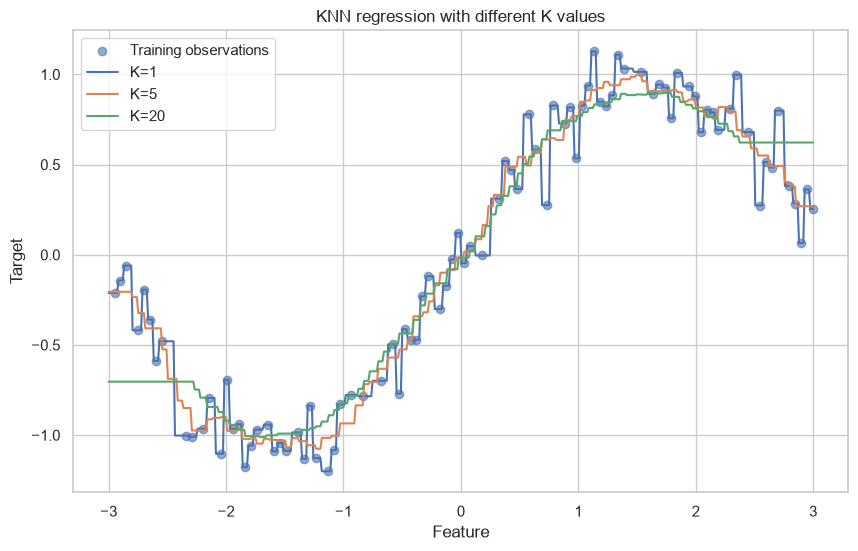

In [14]:
# Create a smooth one-dimensional nonlinear regression problem.
rng = np.random.RandomState(42)

# Generate sorted input values for a visually clean regression example.
X_reg = np.linspace(-3.0, 3.0, 120).reshape(-1, 1)

# Generate a nonlinear target using a sine function plus Gaussian noise.
y_reg = (
    np.sin(X_reg[:, 0])
    + 0.15 * rng.randn(len(X_reg))
)

# Split the regression data into training and test sets.
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.25,
    random_state=42
)

# Create three KNN regressors with different K values.
regressors = {
    1: KNeighborsRegressor(n_neighbors=1),
    5: KNeighborsRegressor(n_neighbors=5),
    20: KNeighborsRegressor(n_neighbors=20)
}

# Generate a dense set of x values for smooth prediction curves.
X_reg_grid = np.linspace(
    X_reg.min(),
    X_reg.max(),
    500
).reshape(-1, 1)

# Create a figure.
plt.figure(figsize=(10, 6))

# Plot the training points.
plt.scatter(
    X_reg_train[:, 0],
    y_reg_train,
    alpha=0.6,
    label="Training observations"
)

# Plot the predictions from each K value.
for k, model in regressors.items():

    # Fit the current KNN regressor.
    model.fit(
        X_reg_train,
        y_reg_train
    )

    # Predict on the dense grid.
    y_reg_grid = model.predict(
        X_reg_grid
    )

    # Plot the prediction curve.
    plt.plot(
        X_reg_grid[:, 0],
        y_reg_grid,
        label=f"K={k}"
    )

# Label the axes.
plt.xlabel("Feature")
plt.ylabel("Target")

# Add the title.
plt.title("KNN regression with different K values")

# Display the legend.
plt.legend()

# Show the plot.
plt.show()

## 10.1 Interpreting the Regression Plot

The same bias-variance idea appears here:

- $K=1$ can follow the training points very closely.
- Moderate $K$ values usually smooth the predictions.
- Very large $K$ values can oversmooth important structure.

Again, the correct value is data-dependent.

# 11. Why Feature Scaling Matters in KNN

Distance is the foundation of KNN.

Therefore, if one feature has a much larger numerical scale than another, it can dominate the distance calculation.

### Example

Suppose:

- Age ranges from 20 to 80.
- Annual income ranges from 20,000 to 200,000.

Without scaling, income differences can dominate Euclidean distance.

This does not necessarily mean income is actually more informative.

It may simply have a larger numerical unit.

That is why scaling is often a critical preprocessing step for KNN.

In [15]:
# Create two features with intentionally different numerical scales.
X_scale = np.array([
    [20, 10000],
    [25, 50000],
    [30, 90000],
    [35, 130000],
    [40, 170000],
    [45, 210000]
], dtype=float)

# Create a target with two classes for demonstration.
y_scale = np.array([0, 0, 0, 1, 1, 1])

# Create a StandardScaler object.
scaler_demo = StandardScaler()

# Fit the scaler and transform the entire demonstration dataset.
# This is acceptable here because this is only a mathematical demonstration,
# not a model-validation workflow.
X_scale_standardized = scaler_demo.fit_transform(X_scale)

# Display the original and standardized data.
print("Original data:")
print(X_scale)

print("\nStandardized data:")
print(X_scale_standardized)

Original data:
[[    20.  10000.]
 [    25.  50000.]
 [    30.  90000.]
 [    35. 130000.]
 [    40. 170000.]
 [    45. 210000.]]

Standardized data:
[[-1.464 -1.464]
 [-0.878 -0.878]
 [-0.293 -0.293]
 [ 0.293  0.293]
 [ 0.878  0.878]
 [ 1.464  1.464]]


## 11.1 Standardization Formula

Standardization transforms a feature using:

$$
z=\frac{x-\mu}{\sigma}
$$

where:

- $x$ = original feature value
- $\mu$ = mean of the training feature
- $\sigma$ = standard deviation of the training feature

After standardization, features are typically centered around 0 with approximately unit variance.

### Critical rule

The scaler must learn its parameters from **training data only**:

```python
scaler.fit(X_train)
```

Then apply those learned parameters to other data:

```python
scaler.transform(X_val)
scaler.transform(X_test)
```

This is essential for avoiding data leakage.

# 12. Demonstrating Data Leakage

Suppose you scale the entire dataset before the train/test split:

```python
scaler.fit_transform(X)
```

The mean and standard deviation used for scaling are then influenced by observations that later become part of the test set.

That means information from the test distribution has leaked into preprocessing.

The safer structure is:

```text
Raw data
   ↓
Train/Test split
   ↓
Fit scaler on training data only
   ↓
Transform training and test using the training parameters
   ↓
Fit KNN
```

The safest implementation is usually a `Pipeline`.

In [16]:
# Create a correctly designed KNN pipeline.
safe_knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

# Fit the complete pipeline using the training data only.
safe_knn_pipeline.fit(
    X_curve_train,
    y_curve_train
)

# Predict the held-out test set.
safe_test_prediction = safe_knn_pipeline.predict(
    X_curve_test
)

# Report the final test accuracy.
print(
    "Test accuracy:",
    accuracy_score(
        y_curve_test,
        safe_test_prediction
    )
)

Test accuracy: 0.9


# 13. KNN From Scratch

Before using scikit-learn, it is useful to implement the core algorithm ourselves.

Our educational implementation will:

1. store the training data
2. compute Euclidean distances
3. sort the neighbors
4. select the first $K$
5. perform majority voting

This implementation is intentionally simple so that each step corresponds directly to the mathematics.

In [17]:
# Define a function that calculates Euclidean distance between two vectors.
def euclidean_distance(x1, x2):

    # Subtract corresponding feature values.
    difference = x1 - x2

    # Square every coordinate difference.
    squared_difference = difference ** 2

    # Add the squared differences.
    sum_squared_difference = np.sum(squared_difference)

    # Take the square root and return the distance.
    return np.sqrt(sum_squared_difference)


# Define a simple KNN classifier implemented from scratch.
class KNNClassifierScratch:

    # Define the constructor and store the value of K.
    def __init__(self, k=3):

        # Check that K is a positive integer.
        if not isinstance(k, int) or k <= 0:
            raise ValueError("k must be a positive integer.")

        # Store K inside the object.
        self.k = k

        # Initialize training data placeholders.
        self.X_train = None
        self.y_train = None

    # Define the fit method.
    def fit(self, X, y):

        # Convert X into a NumPy array.
        X = np.asarray(X)

        # Convert y into a NumPy array.
        y = np.asarray(y)

        # Check that X is two-dimensional.
        if X.ndim != 2:
            raise ValueError("X must be a 2D array.")

        # Check that the number of samples in X and y match.
        if len(X) != len(y):
            raise ValueError("X and y must have the same number of samples.")

        # Check that K does not exceed the number of training observations.
        if self.k > len(X):
            raise ValueError("k cannot be larger than the number of training samples.")

        # Store the training features.
        self.X_train = X

        # Store the training labels.
        self.y_train = y

        # Return self so the object follows the familiar fit API.
        return self

    # Define a helper method for predicting one sample.
    def _predict_one(self, x):

        # Create an empty list for distances and labels.
        neighbors = []

        # Loop over every training sample.
        for x_train, label in zip(self.X_train, self.y_train):

            # Calculate the Euclidean distance to the training sample.
            distance = euclidean_distance(x, x_train)

            # Store the distance and corresponding label.
            neighbors.append((distance, label))

        # Sort neighbors from nearest to farthest.
        neighbors.sort(key=lambda item: item[0])

        # Select the K closest observations.
        nearest = neighbors[:self.k]

        # Extract the labels of the nearest observations.
        labels = np.array([label for _, label in nearest])

        # Count the occurrences of each class.
        classes, counts = np.unique(
            labels,
            return_counts=True
        )

        # Select the class with the largest number of votes.
        prediction = classes[np.argmax(counts)]

        # Return the predicted class.
        return prediction

    # Define the public predict method.
    def predict(self, X):

        # Convert the input into a NumPy array.
        X = np.asarray(X)

        # Check that X is two-dimensional.
        if X.ndim != 2:
            raise ValueError("X must be a 2D array.")

        # Predict every row independently.
        predictions = [
            self._predict_one(x)
            for x in X
        ]

        # Return predictions as a NumPy array.
        return np.asarray(predictions)

## 13.1 Test the Scratch Implementation

We now compare our implementation with scikit-learn on the same small dataset.

The goal is not to reproduce every internal optimization of scikit-learn.

The goal is to verify that our conceptual implementation follows the expected KNN logic.

In [18]:
# Create a small training dataset.
X_scratch = np.array([
    [1, 1],
    [2, 2],
    [2, 3],
    [8, 8],
    [9, 9],
    [8, 9]
], dtype=float)

# Create the class labels.
y_scratch = np.array([0, 0, 0, 1, 1, 1])

# Create a test point.
X_scratch_test = np.array([
    [3, 2],
    [8, 7]
], dtype=float)

# Create the scratch KNN model with K=3.
scratch_model = KNNClassifierScratch(k=3)

# Fit the scratch model.
scratch_model.fit(
    X_scratch,
    y_scratch
)

# Generate scratch predictions.
scratch_predictions = scratch_model.predict(
    X_scratch_test
)

# Print the scratch predictions.
print("Scratch predictions:", scratch_predictions)

# Create the corresponding scikit-learn model.
sklearn_model = KNeighborsClassifier(
    n_neighbors=3
)

# Fit the scikit-learn model.
sklearn_model.fit(
    X_scratch,
    y_scratch
)

# Generate scikit-learn predictions.
sklearn_predictions = sklearn_model.predict(
    X_scratch_test
)

# Print the scikit-learn predictions.
print("Scikit-learn predictions:", sklearn_predictions)

# Confirm whether both implementations agree.
print(
    "Predictions agree:",
    np.array_equal(
        scratch_predictions,
        sklearn_predictions
    )
)

Scratch predictions: [0 1]


Scikit-learn predictions: [0 1]
Predictions agree: True


# 14. Distance-Weighted KNN From Scratch

Now we can extend the idea so that closer neighbors receive larger weights.

For classification, define:

$$
S_c
=
\sum_{i\in N_k(x)}
w_i\mathbf{1}(y_i=c)
$$

and choose:

$$
\hat y
=
\arg\max_c S_c
$$

A practical educational weighting rule is:

$$
w_i = \frac{1}{d_i+\epsilon}
$$

where $\epsilon$ is a small positive number that prevents division by zero.

In [19]:
# Define a weighted KNN classifier from scratch.
class WeightedKNNClassifierScratch:

    # Define the constructor.
    def __init__(self, k=5, epsilon=1e-9):

        # Validate the K argument.
        if not isinstance(k, int) or k <= 0:
            raise ValueError("k must be a positive integer.")

        # Validate the epsilon argument.
        if epsilon <= 0:
            raise ValueError("epsilon must be positive.")

        # Store K.
        self.k = k

        # Store epsilon.
        self.epsilon = epsilon

        # Initialize training attributes.
        self.X_train = None
        self.y_train = None

    # Define the fit method.
    def fit(self, X, y):

        # Convert X into a NumPy array.
        X = np.asarray(X)

        # Convert y into a NumPy array.
        y = np.asarray(y)

        # Validate the feature matrix.
        if X.ndim != 2:
            raise ValueError("X must be a 2D array.")

        # Validate the sample counts.
        if len(X) != len(y):
            raise ValueError("X and y must have the same number of samples.")

        # Validate K.
        if self.k > len(X):
            raise ValueError("k cannot be larger than the number of training samples.")

        # Store training features.
        self.X_train = X

        # Store training labels.
        self.y_train = y

        # Return the fitted object.
        return self

    # Define the prediction method for a single sample.
    def _predict_one(self, x):

        # Create an empty list for distance-label pairs.
        neighbors = []

        # Loop through every training sample.
        for x_train, label in zip(self.X_train, self.y_train):

            # Compute Euclidean distance.
            distance = euclidean_distance(x, x_train)

            # Compute an inverse-distance weight.
            weight = 1.0 / (distance + self.epsilon)

            # Store distance, label, and weight.
            neighbors.append((distance, label, weight))

        # Sort by distance from nearest to farthest.
        neighbors.sort(key=lambda item: item[0])

        # Keep only the K nearest observations.
        nearest = neighbors[:self.k]

        # Create a dictionary for class-weight totals.
        class_scores = {}

        # Add the weighted vote of each neighbor.
        for _, label, weight in nearest:

            # Create the key if the class has not appeared yet.
            if label not in class_scores:
                class_scores[label] = 0.0

            # Add the neighbor's weight to its class score.
            class_scores[label] += weight

        # Select the class with the highest weighted score.
        prediction = max(
            class_scores,
            key=class_scores.get
        )

        # Return the predicted class.
        return prediction

    # Define the public predict method.
    def predict(self, X):

        # Convert input data into a NumPy array.
        X = np.asarray(X)

        # Validate dimensionality.
        if X.ndim != 2:
            raise ValueError("X must be a 2D array.")

        # Predict each observation separately.
        predictions = [
            self._predict_one(x)
            for x in X
        ]

        # Convert predictions to a NumPy array.
        return np.asarray(predictions)

# 15. KNN Classification with Scikit-learn

Now that the core mechanics are understood, the scikit-learn implementation becomes straightforward.

The standard workflow is:

```text
Split
  ↓
Scale
  ↓
Fit KNN
  ↓
Predict
  ↓
Evaluate
```

A `Pipeline` is preferred when preprocessing is part of the model workflow.

In [20]:
# Create a fresh binary classification dataset.
X_ml, y_ml = make_classification(
    n_samples=800,
    n_features=8,
    n_informative=5,
    n_redundant=0,
    class_sep=1.3,
    random_state=42
)

# Split the data into training and test subsets.
X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X_ml,
    y_ml,
    test_size=0.20,
    random_state=42,
    stratify=y_ml
)

# Build a standard pipeline with scaling and KNN.
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=7))
])

# Fit the pipeline on the training data.
knn_pipeline.fit(
    X_train_ml,
    y_train_ml
)

# Predict the test set.
y_pred_ml = knn_pipeline.predict(
    X_test_ml
)

# Calculate test accuracy.
test_accuracy = accuracy_score(
    y_test_ml,
    y_pred_ml
)

# Print the result.
print("Test accuracy:", test_accuracy)

Test accuracy: 0.8875


# 16. Evaluating KNN Classification

Accuracy is:

$$
Accuracy
=
\frac{TP+TN}
{TP+TN+FP+FN}
$$

But accuracy alone can be misleading, especially when classes are imbalanced.

We should also understand:

### Precision

$$
Precision
=
\frac{TP}
{TP+FP}
$$

### Recall

$$
Recall
=
\frac{TP}
{TP+FN}
$$

### F1-score

$$
F1
=
2
\frac{
Precision \cdot Recall
}{
Precision+Recall
}
$$

These metrics answer different questions, so the appropriate metric depends on the scientific or business objective.

In [21]:
# Calculate accuracy.
accuracy = accuracy_score(
    y_test_ml,
    y_pred_ml
)

# Calculate precision for binary classification.
precision = precision_score(
    y_test_ml,
    y_pred_ml
)

# Calculate recall for binary classification.
recall = recall_score(
    y_test_ml,
    y_pred_ml
)

# Calculate the F1-score.
f1 = f1_score(
    y_test_ml,
    y_pred_ml
)

# Print the metrics.
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

# Print the complete classification report.
print("\nClassification report:")
print(
    classification_report(
        y_test_ml,
        y_pred_ml
    )
)

Accuracy : 0.8875
Precision: 0.8875
Recall   : 0.8875
F1-score : 0.8875

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        80
           1       0.89      0.89      0.89        80

    accuracy                           0.89       160
   macro avg       0.89      0.89      0.89       160
weighted avg       0.89      0.89      0.89       160



# 17. Confusion Matrix

For binary classification, the confusion matrix contains:

- True Positives
- True Negatives
- False Positives
- False Negatives

The exact interpretation depends on which class is considered positive.

This is especially important in medical classification because false positives and false negatives can have very different consequences.

[[71  9]
 [ 9 71]]


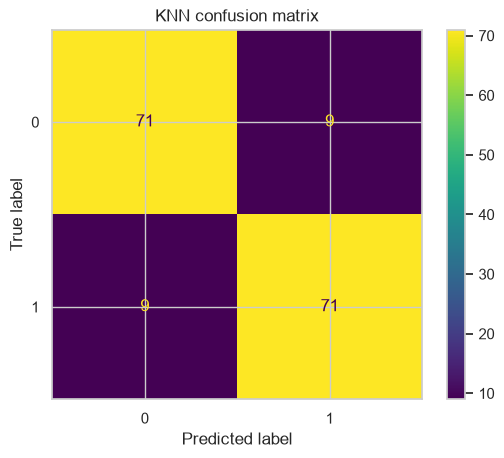

In [22]:
# Calculate the confusion matrix.
cm = confusion_matrix(
    y_test_ml,
    y_pred_ml
)

# Print the raw matrix.
print(cm)

# Create a visualization of the confusion matrix.
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

# Plot the confusion matrix.
disp.plot()

# Add a descriptive title.
plt.title("KNN confusion matrix")

# Display the figure.
plt.show()

# 18. KNN Probability Estimates and ROC-AUC

`KNeighborsClassifier` can provide probability estimates.

For uniform weights, these can be understood as the proportion of neighbors belonging to each class.

For example, if:

- 7 of 10 neighbors are class 1
- 3 of 10 neighbors are class 0

the estimated probability for class 1 is approximately 0.70 under uniform weighting.

These probabilities are useful for threshold-based metrics such as ROC-AUC.

Note that KNN probability estimates should not automatically be interpreted as perfectly calibrated clinical probabilities.

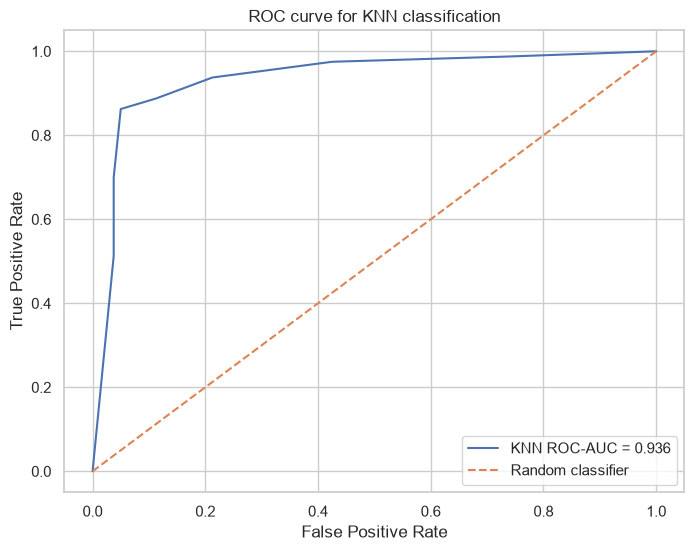

In [23]:
# Generate positive-class probability estimates.
y_probability = knn_pipeline.predict_proba(
    X_test_ml
)[:, 1]

# Compute the ROC curve.
false_positive_rate, true_positive_rate, thresholds = roc_curve(
    y_test_ml,
    y_probability
)

# Compute the area under the ROC curve.
auc_score = roc_auc_score(
    y_test_ml,
    y_probability
)

# Create the ROC plot.
plt.figure(figsize=(8, 6))

# Plot the ROC curve.
plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"KNN ROC-AUC = {auc_score:.3f}"
)

# Plot the diagonal reference line.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

# Label the axes.
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

# Add the title.
plt.title("ROC curve for KNN classification")

# Display the legend.
plt.legend()

# Show the plot.
plt.show()

# 19. Cross-Validation

A single train/validation split can be noisy.

**Cross-validation (CV)** provides a more stable estimate by repeatedly training and evaluating the model on different subsets.

For example, in 5-fold cross-validation:

```text
Fold 1 → validation
Fold 2 → validation
Fold 3 → validation
Fold 4 → validation
Fold 5 → validation
```

Each sample is used for validation exactly once across the full procedure.

For classification, `StratifiedKFold` is usually appropriate because it attempts to preserve class proportions in each fold.

In [24]:
# Create a 5-fold stratified cross-validation strategy.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Create a KNN pipeline for cross-validation.
cv_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=7))
])

# Compute the five cross-validation accuracy scores.
cv_scores = cross_val_score(
    cv_pipeline,
    X_train_ml,
    y_train_ml,
    cv=cv,
    scoring="accuracy"
)

# Print every fold score.
print("Fold scores:", cv_scores)

# Print the mean score.
print("Mean CV accuracy:", cv_scores.mean())

# Print the standard deviation to show variation across folds.
print("CV standard deviation:", cv_scores.std())

Fold scores: [0.875 0.898 0.898 0.875 0.875]
Mean CV accuracy: 0.884375
CV standard deviation: 0.011481983169296146


# 20. Hyperparameter Tuning with GridSearchCV

Important KNN hyperparameters include:

- `n_neighbors`
- `weights`
- `metric`
- `p`

A grid search evaluates combinations of candidate values using cross-validation.

We will use a pipeline so that **scaling happens separately inside each training fold**.

This is a critical best practice.

In [25]:
# Build a pipeline for grid search.
grid_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

# Define candidate hyperparameter values.
param_grid = {
    "knn__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2]
}

# Create a GridSearchCV object.
grid_search = GridSearchCV(
    estimator=grid_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

# Fit the complete grid search on training data only.
grid_search.fit(
    X_train_ml,
    y_train_ml
)

# Print the best hyperparameters found by cross-validation.
print("Best parameters:")
print(grid_search.best_params_)

# Print the best cross-validation score.
print("\nBest mean CV accuracy:")
print(grid_search.best_score_)

# Evaluate the selected model on the untouched test set.
grid_test_prediction = grid_search.predict(
    X_test_ml
)

# Print the final test accuracy.
print("\nFinal test accuracy:")
print(
    accuracy_score(
        y_test_ml,
        grid_test_prediction
    )
)

Best parameters:
{'knn__n_neighbors': 21, 'knn__p': 1, 'knn__weights': 'uniform'}

Best mean CV accuracy:
0.8984375

Final test accuracy:
0.89375


## 20.1 Inspecting Grid Search Results

The search results are stored in `cv_results_`.

This allows us to compare hyperparameter combinations rather than only looking at the single best model.

In [26]:
# Convert the grid-search results into a pandas DataFrame.
grid_results = pd.DataFrame(
    grid_search.cv_results_
)

# Keep only the most useful columns for inspection.
selected_columns = [
    "param_knn__n_neighbors",
    "param_knn__weights",
    "param_knn__p",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]

# Display the best configurations first.
display(
    grid_results[selected_columns]
    .sort_values("rank_test_score")
    .head(15)
)

,param_knn__n_neighbors,param_knn__weights,param_knn__p,mean_test_score,std_test_score,rank_test_score
29,21,distance,1,0.898438,0.020963,1
28,21,uniform,1,0.898438,0.021538,1
21,11,distance,1,0.892188,0.024902,3
23,11,distance,2,0.892188,0.024407,3
24,15,uniform,1,0.892188,0.019390,3
25,15,distance,1,0.892188,0.020010,3
20,11,uniform,1,0.890625,0.022643,7
22,11,uniform,2,0.889062,0.025864,8
26,15,uniform,2,0.889062,0.030217,8
17,9,distance,1,0.887500,0.025000,10


# 21. KNN Regression with Scikit-learn

For regression, use:

```python
KNeighborsRegressor
```

Important parameters are similar to classification:

- `n_neighbors`
- `weights`
- `metric`
- `p`

A regression workflow can also be placed inside a pipeline.

In [27]:
# Build a KNN regression pipeline.
reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=7))
])

# Fit the regression pipeline.
reg_pipeline.fit(
    X_reg_train,
    y_reg_train
)

# Predict the test set.
y_reg_prediction = reg_pipeline.predict(
    X_reg_test
)

# Import the mean squared error metric.
from sklearn.metrics import mean_squared_error

# Calculate the test MSE.
mse = mean_squared_error(
    y_reg_test,
    y_reg_prediction
)

# Print the result.
print("Test MSE:", mse)

Test MSE: 0.019992119025668168


In [28]:
# Create a KNN regression model with distance weighting.
weighted_regressor = KNeighborsRegressor(
    n_neighbors=7,
    weights="distance"
)

# Fit the weighted regressor.
weighted_regressor.fit(
    X_reg_train,
    y_reg_train
)

# Predict on the regression test set.
weighted_prediction = weighted_regressor.predict(
    X_reg_test
)

# Calculate the mean squared error.
weighted_mse = mean_squared_error(
    y_reg_test,
    weighted_prediction
)

# Print the weighted model's test MSE.
print("Distance-weighted KNN MSE:", weighted_mse)

Distance-weighted KNN MSE: 0.02136093285399636


# 22. Inspecting the Actual Neighbors

One of the most useful conceptual exercises is to inspect exactly which observations KNN selected.

`NearestNeighbors` can return neighbor indices and distances.

This makes the algorithm's behavior directly observable.

In [29]:
# Create a nearest-neighbor search object.
neighbor_search = NearestNeighbors(
    n_neighbors=5,
    metric="euclidean"
)

# Fit the search object using the training features.
neighbor_search.fit(
    X_small
)

# Ask for neighbors of the new observation.
distances, indices = neighbor_search.kneighbors(
    x_new.reshape(1, -1)
)

# Flatten the first query's results for convenient display.
distances = distances[0]
indices = indices[0]

# Build a table showing the selected neighbors.
neighbor_details = pd.DataFrame({
    "Training Index": indices,
    "Distance": distances,
    "Class": y_small[indices]
})

# Display the neighbor table.
display(
    neighbor_details
)

,Training Index,Distance,Class
0,1,0.100000,0
1,2,0.900000,0
2,0,1.486607,0
3,3,8.414868,1
4,4,9.829039,1


# 23. A Visual Experiment: KNN Before and After Scaling

We can deliberately create a dataset where one feature is stretched.

The goal is to see that the geometry of the feature space changes when scales are different.

Important:

> Scaling does not magically make the data "better." It changes the geometry so that features are compared on a more comparable scale.

In [30]:
# Generate a two-dimensional classification dataset.
X_scale_effect, y_scale_effect = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    class_sep=1.3,
    random_state=42
)

# Stretch the second feature by a factor of 100.
X_scale_effect_unscaled = X_scale_effect.copy()
X_scale_effect_unscaled[:, 1] *= 100.0

# Split the stretched data into training and test sets.
X_se_train, X_se_test, y_se_train, y_se_test = train_test_split(
    X_scale_effect_unscaled,
    y_scale_effect,
    test_size=0.25,
    random_state=42,
    stratify=y_scale_effect
)

# Create a KNN model without scaling.
unscaled_knn = KNeighborsClassifier(
    n_neighbors=11
)

# Fit the unscaled model.
unscaled_knn.fit(
    X_se_train,
    y_se_train
)

# Create a pipeline that scales before KNN.
scaled_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=11))
])

# Fit the scaled pipeline.
scaled_knn.fit(
    X_se_train,
    y_se_train
)

# Compute test accuracy for the unscaled model.
unscaled_accuracy = accuracy_score(
    y_se_test,
    unscaled_knn.predict(X_se_test)
)

# Compute test accuracy for the scaled model.
scaled_accuracy = accuracy_score(
    y_se_test,
    scaled_knn.predict(X_se_test)
)

# Print both results.
print("Unscaled accuracy:", unscaled_accuracy)
print("Scaled accuracy  :", scaled_accuracy)

Unscaled accuracy:

 0.616
Scaled accuracy  : 0.944


# 24. Curse of Dimensionality

KNN depends on the idea that nearby points are meaningfully similar.

In high-dimensional spaces, several difficult effects appear.

As dimensionality increases:

- the volume of the feature space grows rapidly
- data become sparse
- more observations are needed to maintain local density
- nearest and farthest distances can become relatively less distinguishable

This is part of the **curse of dimensionality**.

The effect is especially important for biological datasets, where one sample can have thousands of molecular features.

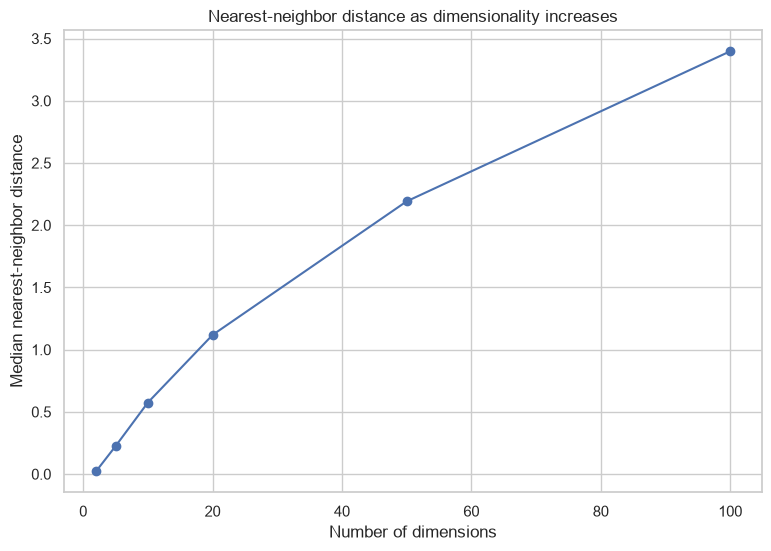

In [31]:
# Define dimensionalities for the experiment.
dimensions = [2, 5, 10, 20, 50, 100]

# Create an empty list for the median nearest-neighbor distance.
median_nearest_distances = []

# Use the same number of random points at every dimensionality.
n_points = 400

# Loop through each dimensionality.
for dimension in dimensions:

    # Create random points inside a unit hypercube.
    X_high_dim = np.random.RandomState(42).rand(
        n_points,
        dimension
    )

    # Create a nearest-neighbor search object.
    nn = NearestNeighbors(
        n_neighbors=2
    )

    # Fit the search structure.
    nn.fit(
        X_high_dim
    )

    # Find the nearest neighbor for every point.
    distances, _ = nn.kneighbors(
        X_high_dim
    )

    # Ignore the first distance because it is each point's distance to itself.
    nearest_distances = distances[:, 1]

    # Store the median nearest-neighbor distance.
    median_nearest_distances.append(
        np.median(nearest_distances)
    )

# Create the plot.
plt.figure(figsize=(9, 6))

# Plot dimension against the median nearest-neighbor distance.
plt.plot(
    dimensions,
    median_nearest_distances,
    marker="o"
)

# Label the axes.
plt.xlabel("Number of dimensions")
plt.ylabel("Median nearest-neighbor distance")

# Add a descriptive title.
plt.title("Nearest-neighbor distance as dimensionality increases")

# Show the plot.
plt.show()

## 24.1 Relative Concentration of Distances

Another useful demonstration is to examine how the spread of pairwise distances changes with dimensionality.

We can calculate the coefficient of variation:

$$
CV = \frac{\sigma_d}{\mu_d}
$$

where:

- $\sigma_d$ = standard deviation of distances
- $\mu_d$ = mean distance

A smaller relative spread means that distances become more similar to one another.

This helps explain why "nearest" can become less informative in very high-dimensional spaces.

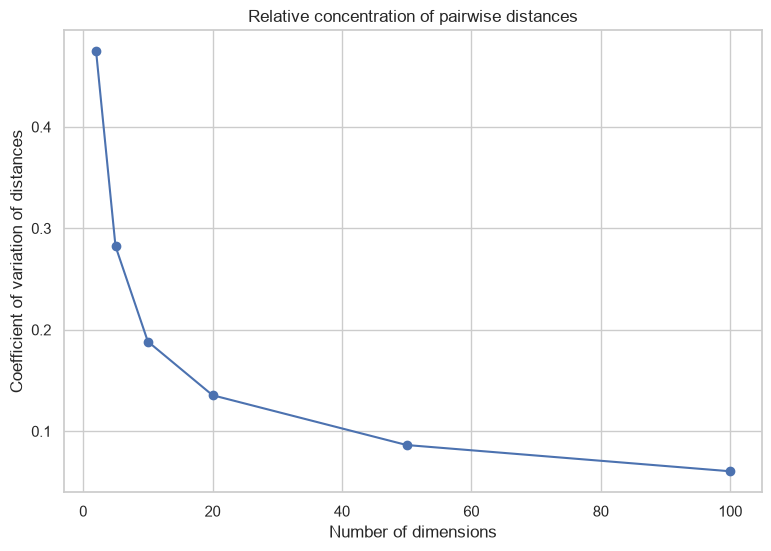

In [32]:
# Define dimensionalities for the distance-concentration experiment.
dimensions_cv = [2, 5, 10, 20, 50, 100]

# Create a list for the coefficient of variation values.
distance_cv_values = []

# Loop through each dimensionality.
for dimension in dimensions_cv:

    # Generate random points in the specified dimension.
    points = np.random.RandomState(123).rand(
        250,
        dimension
    )

    # Generate two random index arrays to create random point pairs.
    rng = np.random.RandomState(123)
    indices_a = rng.randint(
        0,
        len(points),
        size=5000
    )
    indices_b = rng.randint(
        0,
        len(points),
        size=5000
    )

    # Compute Euclidean distance for every random pair.
    pair_distances = np.sqrt(
        np.sum(
            (points[indices_a] - points[indices_b]) ** 2,
            axis=1
        )
    )

    # Remove pairs that selected the same point.
    pair_distances = pair_distances[pair_distances > 0]

    # Calculate the coefficient of variation.
    cv_value = (
        np.std(pair_distances)
        / np.mean(pair_distances)
    )

    # Store the result.
    distance_cv_values.append(cv_value)

# Create the plot.
plt.figure(figsize=(9, 6))

# Plot the relative distance spread.
plt.plot(
    dimensions_cv,
    distance_cv_values,
    marker="o"
)

# Label the axes.
plt.xlabel("Number of dimensions")
plt.ylabel("Coefficient of variation of distances")

# Add the title.
plt.title("Relative concentration of pairwise distances")

# Show the plot.
plt.show()

# 25. Building a Decision Boundary Plot Manually

`mglearn` is convenient, but it is also valuable to understand what a decision-boundary plot is actually doing.

The basic idea is:

1. Create a dense grid covering the feature space.
2. Ask the classifier for a prediction at every grid point.
3. Reshape the predictions back into a 2D grid.
4. Use `contourf` or `pcolormesh` to color the regions.

This concept generalizes to many classifiers, not just KNN.

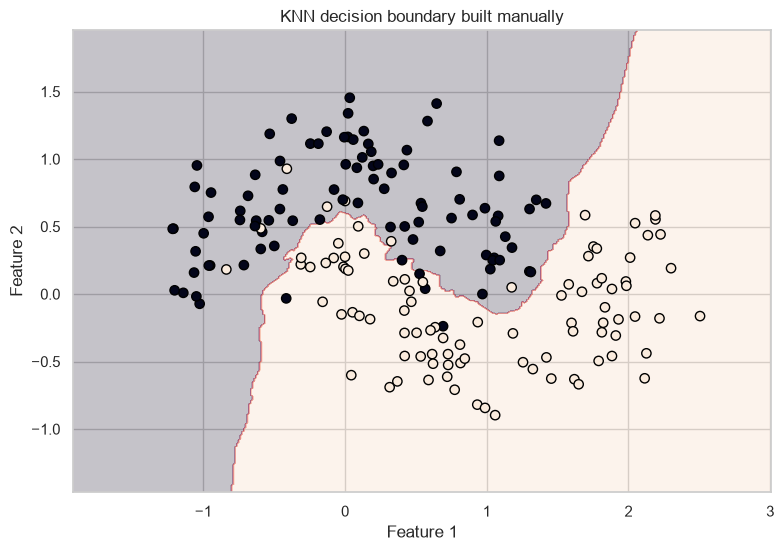

In [33]:
# Train a simple KNN model on the two-dimensional moons data.
manual_boundary_model = KNeighborsClassifier(
    n_neighbors=9
)

# Fit the model.
manual_boundary_model.fit(
    X_moons_train,
    y_moons_train
)

# Find the minimum and maximum values of feature 1.
x_min = X_moons[:, 0].min() - 0.5
x_max = X_moons[:, 0].max() + 0.5

# Find the minimum and maximum values of feature 2.
y_min = X_moons[:, 1].min() - 0.5
y_max = X_moons[:, 1].max() + 0.5

# Create evenly spaced coordinates for the grid.
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

# Flatten the grid so every location becomes one row.
grid_points = np.c_[
    xx.ravel(),
    yy.ravel()
]

# Predict the class at every grid location.
grid_predictions = manual_boundary_model.predict(
    grid_points
)

# Reshape predictions back to the grid shape.
grid_predictions = grid_predictions.reshape(
    xx.shape
)

# Create the figure.
plt.figure(figsize=(9, 6))

# Plot the predicted class regions.
plt.contourf(
    xx,
    yy,
    grid_predictions,
    alpha=0.25
)

# Overlay the training points.
plt.scatter(
    X_moons_train[:, 0],
    X_moons_train[:, 1],
    c=y_moons_train,
    edgecolor="black",
    s=45
)

# Label the axes.
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Add the title.
plt.title("KNN decision boundary built manually")

# Show the plot.
plt.show()

# 26. A More Realistic Binary Classification Example

To practice an end-to-end workflow, we will generate a moderately sized dataset with:

- multiple numerical features
- two target classes
- class-balanced train/test splitting
- scaling
- KNN
- classification metrics

The same structure can later be adapted to tabular biomedical data.

In [34]:
# Generate a more realistic synthetic biomedical-style classification dataset.
X_bio, y_bio = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=8,
    n_redundant=4,
    weights=[0.6, 0.4],
    class_sep=1.0,
    random_state=42
)

# Convert the array into a DataFrame for easier feature inspection.
feature_names = [
    f"Feature_{i:02d}"
    for i in range(1, X_bio.shape[1] + 1)
]

# Build the DataFrame.
bio_df = pd.DataFrame(
    X_bio,
    columns=feature_names
)

# Add the target variable to the table.
bio_df["Target"] = y_bio

# Display the first few observations.
display(
    bio_df.head()
)

# Display class frequencies.
print("Class distribution:")
print(
    bio_df["Target"].value_counts(
        normalize=False
    )
)

,Feature_01,Feature_02,Feature_03,Feature_04,Feature_05,Feature_06,Feature_07,Feature_08,Feature_09,Feature_10,...,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20,Target
0,-1.785685,-0.171279,-6.218932,0.713984,0.757044,-1.479420,-4.376408,-1.790883,-1.671467,-0.705173,...,1.127942,-2.646860,-0.453588,0.850840,-1.360049,1.036402,2.824055,-1.182958,1.231651,1
1,2.486343,8.597156,1.611308,-1.444629,0.641383,-2.686572,-1.529666,-1.455728,-0.871843,-0.704909,...,-1.802738,-0.448516,4.139501,-0.662994,1.251065,0.744432,2.883143,1.136805,-0.202695,1
2,-2.434267,5.607164,-0.101305,2.600187,-1.759978,-2.015222,-2.383526,0.187761,-0.064024,0.201106,...,0.370905,-0.096340,-0.378906,1.168584,-0.463209,0.652645,2.722576,0.283665,-0.701029,0
3,3.785395,-4.385632,0.120542,-0.249513,-0.323815,-1.303417,-2.001176,0.172906,0.724815,-0.538535,...,-1.661279,-1.897091,-1.747958,-0.808466,0.348661,-0.260669,-1.518439,0.369946,1.758268,0
4,2.159234,0.767760,2.145039,-1.670315,0.867609,0.835388,0.793042,0.757124,0.291955,-0.408711,...,0.243559,0.898757,0.598785,-0.194594,2.575753,-0.279949,-0.048571,0.542925,-0.250054,0


Class distribution:
Target
0    600
1    400
Name: count, dtype: int64


In [35]:
# Separate predictors from the target variable.
X_bio = bio_df.drop(
    columns="Target"
)

# Extract the target labels.
y_bio = bio_df["Target"]

# Split the data using stratification.
X_bio_train, X_bio_test, y_bio_train, y_bio_test = train_test_split(
    X_bio,
    y_bio,
    test_size=0.20,
    random_state=42,
    stratify=y_bio
)

# Build a complete preprocessing-and-modeling pipeline.
bio_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=9,
        weights="distance"
    ))
])

# Fit the pipeline on training data.
bio_pipeline.fit(
    X_bio_train,
    y_bio_train
)

# Generate test predictions.
y_bio_pred = bio_pipeline.predict(
    X_bio_test
)

# Print the classification report.
print(
    classification_report(
        y_bio_test,
        y_bio_pred
    )
)

              precision    recall  f1-score   support

           0       0.85      0.88      0.87       120
           1       0.81      0.76      0.79        80

    accuracy                           0.83       200
   macro avg       0.83      0.82      0.83       200
weighted avg       0.83      0.83      0.83       200



# 27. Strengths of KNN

### 1. Simple concept

The algorithm is easy to explain geometrically.

### 2. Flexible decision boundaries

KNN can represent nonlinear decision regions without explicitly specifying a parametric functional form.

### 3. Classification and regression

The same neighborhood idea supports both tasks.

### 4. Few modeling assumptions

KNN does not assume a linear relationship between predictors and target.

### 5. Useful as a baseline

KNN can serve as a useful reference model before moving to more complex methods.

# 28. Weaknesses of KNN

### 1. Sensitive to feature scale

Distance depends directly on numerical scale.

### 2. Sensitive to irrelevant features

An irrelevant dimension still contributes to distance unless removed or down-weighted.

### 3. Sensitive to high dimensionality

Distances can become less informative as dimensionality increases.

### 4. Prediction can be computationally expensive

Many training observations may need to be considered during neighbor search.

### 5. Memory-intensive relative to some parametric models

The training observations must remain available for neighborhood lookup.

### 6. Sensitive to noisy observations when K is small

A noisy training point can dominate its local neighborhood.

# 29. Common KNN Mistakes

## Mistake 1 — No scaling

Using raw features with very different units can distort distances.

## Mistake 2 — Scaling before the train/test split

This can leak information from the test set.

## Mistake 3 — Choosing K from the test set

The test set should be reserved for final evaluation.

## Mistake 4 — Using only accuracy

Accuracy may hide poor minority-class performance.

## Mistake 5 — Using too many irrelevant features

Uninformative dimensions can damage neighborhood quality.

## Mistake 6 — Assuming larger K is always better

Large K can oversmooth the model and cause underfitting.

## Mistake 7 — Assuming K=1 is always the best local model

K=1 can memorize noise and show high variance.

## Mistake 8 — Forgetting the problem type

Classification needs voting; regression needs numeric aggregation.

## Mistake 9 — Treating probability estimates as guaranteed calibrated probabilities

KNN probabilities are neighborhood-based estimates and may require calibration depending on the application.

# 30. What About Categorical Features?

Standard Euclidean distance assumes that the features are numerical and that arithmetic differences are meaningful.

For a categorical feature such as:

```text
Sex = Male / Female
```

it is not automatically correct to encode:

```text
Male = 0
Female = 1
```

and then interpret the numerical difference geometrically as if it were a continuous measurement.

For mixed numerical and categorical data, the distance metric and encoding strategy should be chosen carefully.

Possible approaches include:

- appropriate one-hot encoding with attention to distance effects
- custom distance metrics
- mixed-type similarity measures
- domain-specific feature representations

The general lesson is:

> **KNN is only as meaningful as the distance function used to define "similarity."**

# 31. KNN in Bioinformatics and Cancer AI

KNN can be useful in biomedical machine learning as a baseline or exploratory method.

Example feature spaces include:

- gene-expression profiles
- radiomic features
- demographic and clinical variables
- engineered imaging descriptors
- molecular measurements

However, high-dimensional biological data introduce important challenges.

For example, if a dataset contains thousands of genes:

```text
Patients × 10,000 genes
```

then applying raw Euclidean KNN may not be ideal.

A more defensible pipeline could involve:

```text
Quality control
      ↓
Train/test split
      ↓
Feature selection
      ↓
Scaling
      ↓
Optional dimensionality reduction
      ↓
KNN
      ↓
Cross-validation
      ↓
Final test evaluation
```

For a scientific paper, every transformation should be performed in a leakage-safe way and justified scientifically.

# 32. Recommended End-to-End KNN Template

The following code is a compact template that combines the main best practices from the notebook.

In [38]:
# Split the raw data into training and test sets before fitting preprocessing.
X_train, X_test, y_train, y_test = train_test_split(
    X_ml,
    y_ml,
    test_size=0.20,
    random_state=42,
    stratify=y_ml
)

# Build a pipeline so scaling is learned only from the appropriate training folds.
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=7,
        weights="distance",
        p=2
    ))
])

# Fit the pipeline using the training data.
pipeline.fit(
    X_train,
    y_train
)

# Generate predictions on the untouched test set.
y_pred = pipeline.predict(
    X_test
)

# Report classification performance.
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.89      0.90      0.89        80
           1       0.90      0.89      0.89        80

    accuracy                           0.89       160
   macro avg       0.89      0.89      0.89       160
weighted avg       0.89      0.89      0.89       160



# 33. KNN Mastery Checklist

Use this checklist to verify that you understand the algorithm.

### Conceptual understanding

- [ ] I can explain what KNN does.
- [ ] I understand the meaning of a neighbor.
- [ ] I understand exactly what `K` controls.
- [ ] I know why KNN is called instance-based learning.
- [ ] I know why KNN is called lazy learning.

### Mathematics

- [ ] I can calculate Euclidean distance by hand.
- [ ] I can calculate Manhattan distance.
- [ ] I understand Minkowski distance.
- [ ] I understand weighted voting.
- [ ] I understand KNN regression mathematically.
- [ ] I understand the role of feature scaling.

### Generalization

- [ ] I understand why small K can overfit.
- [ ] I understand why large K can underfit.
- [ ] I understand the bias-variance connection.
- [ ] I know why the test set should not be used for hyperparameter selection.

### Scikit-learn

- [ ] I can use `KNeighborsClassifier`.
- [ ] I can use `KNeighborsRegressor`.
- [ ] I can build a `Pipeline`.
- [ ] I can use cross-validation.
- [ ] I can use `GridSearchCV`.
- [ ] I can evaluate classification with a confusion matrix and classification report.

### Advanced understanding

- [ ] I understand the curse of dimensionality.
- [ ] I can inspect actual nearest neighbors.
- [ ] I can draw a decision boundary.
- [ ] I can implement a basic KNN classifier from scratch.
- [ ] I can explain when KNN may be a poor choice.

# 34. References and Learning Notes

## Core references

1. **Pedregosa, F., et al. (2011).** Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.
2. **Buitinck, L., et al. (2013).** API design for machine learning software: experiences from the scikit-learn project. *ECML PKDD Workshop*.
3. **Géron, A.** *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow.* O'Reilly.
4. **Müller, A. C., & Guido, S.** *Introduction to Machine Learning with Python.* O'Reilly.
5. Scikit-learn documentation for `KNeighborsClassifier`, `KNeighborsRegressor`, preprocessing, pipelines, and model selection.

## Personal learning and teaching experience

This notebook also reflects my **personal learning process, practical experimentation, teaching experience, and observations while working with Python, Machine Learning, scientific data analysis, and biomedical/cancer-AI applications**.

These practical notes are used to complement—not replace—the formal references above.

## Important note

Educational examples in this notebook use synthetic or small controlled datasets so that the mathematics and algorithmic behavior can be visualized clearly.

For scientific or clinical work, model decisions should be validated on appropriate datasets, evaluated with task-relevant metrics, and designed with leakage prevention and reproducibility in mind.

# 35. Final Takeaway

The most important idea in KNN is not the line:

```python
KNeighborsClassifier(...)
```

The important idea is:

$$
\boxed{
\text{Define meaningful similarity}
\rightarrow
\text{Find the nearest observations}
\rightarrow
\text{Aggregate their information}
}
$$

Everything else follows from this:

- distance metric
- scaling
- choice of K
- weighted neighbors
- decision boundaries
- cross-validation
- dimensionality reduction
- feature selection
- evaluation

Once this logic is clear, the scikit-learn API becomes an implementation detail rather than the algorithm itself.